# cuTile test

The goal with this notebook is to play around with cuTile and reimplement the 3 lecture in the (gpu-mode)[https://github.com/gpu-mode/lectures]. Thus the goal is to convert the image from color to grey scale, doing this in a parallel fashion in order to utalize the thrughput oriented nature of GPU:s.

In [17]:
%uv pip install cuda-tile torch torchvision cupy-cuda13x matplotlib wurlitzer ninja

Using Python 3.11.5 environment at: /usr/local
Resolved 42 packages in 54ms
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
wurlitzer            ------------------------------ 8.39 KiB/8.39 KiB
⠙ Preparing packages... (0/2)
wurlitzer            ------------------------------ 8.39 KiB/8.39 KiB
⠙ Preparing packages... (0/2)
wurlitzer            ------------------------------ 8.39 KiB/8.39 KiB
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
Prepared 2 packages in 11ms
Installed 2 packages in 192ms
 + ninja==1.13.0
 + wurlitzer==3.1.1
Note: you may need to restart the kernel to use updated packages.


In [21]:
import torch, os, math
import torchvision as tv
import torchvision.transforms.functional as tvf
import matplotlib.pyplot as plt
import torch, os, math, gzip, pickle
import cuda.tile as ct
import cupy
import urllib.request

from torchvision import io
from torch.utils.cpp_extension import load_inline


In [22]:
url = "https://raw.githubusercontent.com/gpu-mode/lectures/main/lecture_003/puppy.jpg"
filename = "puppy.jpg"

urllib.request.urlretrieve(url, filename)
print(f"Downloaded {filename}")

Downloaded puppy.jpg


In [3]:
img = io.read_image('puppy.jpg')
print(img.shape)
img[:2,:3,:4]

torch.Size([3, 1330, 1920])


tensor([[[225, 225, 225, 225],
         [225, 225, 225, 225],
         [225, 225, 225, 225]],

        [[228, 228, 228, 228],
         [228, 228, 228, 228],
         [228, 228, 228, 228]]], dtype=torch.uint8)

In [4]:
def show_img(x, figsize=(4,3), **kwargs):
    plt.figure(figsize=figsize)
    plt.axis('off')
    if len(x.shape)==3: x = x.permute(1,2,0)  # CHW -> HWC
    plt.imshow(x.cpu(), **kwargs)

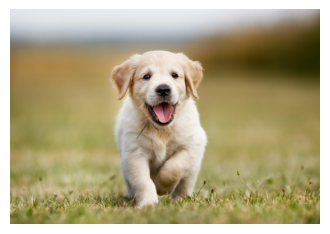

In [5]:
show_img(img)

In [6]:
os.environ['CUDA_LAUNCH_BLOCKING']='1'

def load_cuda(cuda_src, cpp_src, funcs, opt=False, verbose=False):
    return load_inline(cuda_sources=[cuda_src], cpp_sources=[cpp_src], functions=funcs,
                       extra_cuda_cflags=["-O2"] if opt else [], verbose=verbose, name="inline_ext")


cuda_begin = r'''
#include <torch/extension.h>
#include <stdio.h>
#include <c10/cuda/CUDAException.h>

#define CHECK_CUDA(x) TORCH_CHECK(x.device().is_cuda(), #x " must be a CUDA tensor")
#define CHECK_CONTIGUOUS(x) TORCH_CHECK(x.is_contiguous(), #x " must be contiguous")
#define CHECK_INPUT(x) CHECK_CUDA(x); CHECK_CONTIGUOUS(x)

inline unsigned int cdiv(unsigned int a, unsigned int b) { return (a + b - 1) / b;}
'''


cuda_src = cuda_begin + r'''
__global__ void rgb_to_grayscale_kernel(unsigned char* x, unsigned char* out, int n) {
    int i = blockIdx.x*blockDim.x + threadIdx.x;
    if (i<n) out[i] = 0.2989*x[i] + 0.5870*x[i+n] + 0.1140*x[i+2*n];
}

torch::Tensor rgb_to_grayscale(torch::Tensor input) {
    CHECK_INPUT(input);
    int h = input.size(1);
    int w = input.size(2);
    printf("h*w: %d*%d\n", h, w);
    auto output = torch::empty({h,w}, input.options());
    int threads = 256;
    rgb_to_grayscale_kernel<<<cdiv(w*h,threads), threads>>>(
        input.data_ptr<unsigned char>(), output.data_ptr<unsigned char>(), w*h);
    C10_CUDA_KERNEL_LAUNCH_CHECK();
    return output;
}'''

cpp_src = "torch::Tensor rgb_to_grayscale(torch::Tensor input);"

In [7]:
module = load_cuda(cuda_src, cpp_src, ['rgb_to_grayscale'], verbose=True)

[1/3] c++ -MMD -MF main.o.d -DTORCH_EXTENSION_NAME=inline_ext -DTORCH_API_INCLUDE_EXTENSION_H -isystem /usr/local/lib/python3.11/site-packages/torch/include -isystem /usr/local/lib/python3.11/site-packages/torch/include/torch/csrc/api/include -isystem /usr/local/cuda/include -isystem /usr/local/include/python3.11 -fPIC -std=c++17 -c /root/.cache/torch_extensions/py311_cu128/inline_ext/main.cpp -o main.o 
[2/3] /usr/local/cuda/bin/nvcc --generate-dependencies-with-compile --dependency-output cuda.cuda.o.d -DTORCH_EXTENSION_NAME=inline_ext -DTORCH_API_INCLUDE_EXTENSION_H -isystem /usr/local/lib/python3.11/site-packages/torch/include -isystem /usr/local/lib/python3.11/site-packages/torch/include/torch/csrc/api/include -isystem /usr/local/cuda/include -isystem /usr/local/include/python3.11 -D__CUDA_NO_HALF_OPERATORS__ -D__CUDA_NO_HALF_CONVERSIONS__ -D__CUDA_NO_BFLOAT16_CONVERSIONS__ -D__CUDA_NO_HALF2_OPERATORS__ --expt-relaxed-constexpr -gencode=arch=compute_100,code=compute_100 -gencode=a

In [23]:
%%time
imgc = img.contiguous().cuda()

res = module.rgb_to_grayscale(imgc).cpu()

CPU times: user 10 ms, sys: 0 ns, total: 10 ms
Wall time: 6.28 ms


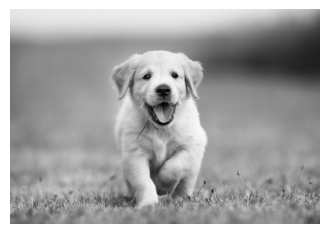

In [13]:
show_img(res, cmap='gray')

# Time to do it in cutile now ... 

In [1]:

TILE_SIZE = 16

@ct.kernel
def rgb_kernel(a, b, tn, tm):
  row_block = ct.bid(0)
  col_block = ct.bid(1)

    # Define weights for RGB to grayscale conversion
  R_WEIGHT = 0.2989
  G_WEIGHT = 0.5870
  B_WEIGHT = 0.1140


  r = ct.load(
        a, 
        index=(0,row_block, col_block), 
        shape=(1,tn, tm)
  )
  g = ct.load(
        a, 
        index=(1,row_block, col_block), 
        shape=(1,tm, tm)
  )
  b = ct.load(
        a, 
        index=(2,row_block, col_block), 
        shape=(1,tn, tm)
  )
    # 3. Extract Channels
    # Slice the tile to get separate R, G, B planes
    # shape becomes (16, 16) for each

    
    # 4. Compute Greyscale (Element-wise math)
    # cuTile handles the broadcasting and element-wise ops automatically
    # This should be broadcasted according to Cutile
  grey_tile = (r * R_WEIGHT) + (g * G_WEIGHT) + (b * B_WEIGHT)
  grey_tile = ct.reshape(grey_tile, shape=(tn, tm))
  
    # 5. Store the 2D Result
    # Output is just (Height, Width), so we store a (16, 16) tile
  ct.store(
        b, 
        index=(row_block, col_block), 
        tile=grey_tile
  )

grid = (ct.cdiv(img.shape[1], TILE_SIZE), ct.cdiv(img.shape[2], TILE_SIZE), 1)
result = torch.zeros((img.shape[1], img.shape[2]), dtype=torch.float32, device='cuda')


img_cuda = img.to(device='cuda')
# Launch the kernel

out = ct.launch(cupy.cuda.get_current_stream(), grid, rgb_kernel, (img_cuda, result, TILE_SIZE, TILE_SIZE))


NameError: name 'ct' is not defined

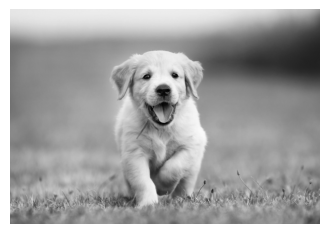

In [29]:
show_img(result, cmap='gray')